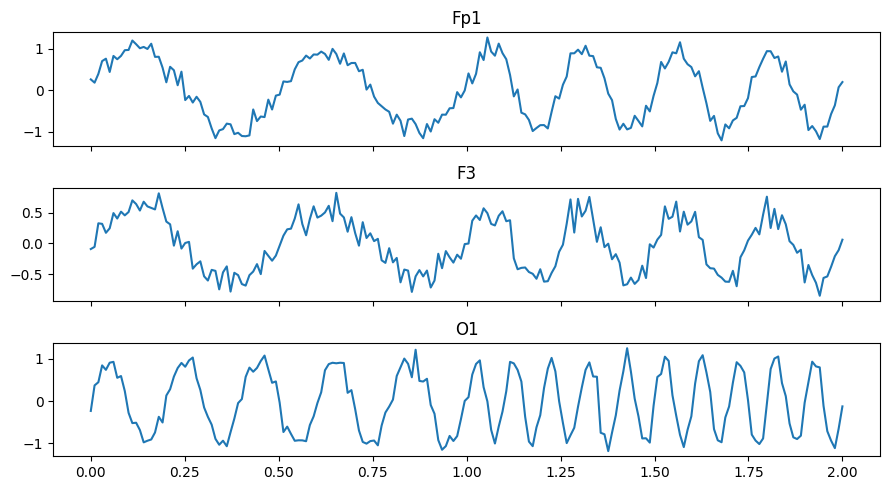

Ham EEG shape: (3, 200)


In [1]:
!pip install vmdpy -q
import numpy as np
import torch
import torch.nn.functional as F
import statsmodels.api as sm
from scipy.stats import f as f_dist
from vmdpy import VMD
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)

C, T = 3, 200
fs = 100
t = np.linspace(0, T/fs, T)
half = T//2

def make_channel(base_freq):
    return np.concatenate([
        np.sin(2*np.pi*base_freq*t[:half]),
        np.sin(2*np.pi*(base_freq*2)*t[half:])
    ]) + 0.15*np.random.randn(T)

raw_eeg = np.stack([make_channel(2), make_channel(2)*0.6 + 0.1*np.random.randn(T), make_channel(5)])
# kanal 0: Fp1 (2Hz->4Hz), kanal 1: F3 (Fp1'e benzer + gürültü), kanal 2: O1 (bağımsız, 5Hz->10Hz)

fig, axes = plt.subplots(3,1, figsize=(9,5), sharex=True)
names = ["Fp1","F3","O1"]
for i,ax in enumerate(axes):
    ax.plot(t, raw_eeg[i]); ax.set_title(names[i])
plt.tight_layout(); plt.show()
print("Ham EEG shape:", raw_eeg.shape)

In [2]:
K = 4
all_modes = []
for c in range(C):
    u, _, _ = VMD(raw_eeg[c], 2000, 0.0, K, 0, 1, 1e-6)
    all_modes.append(u)
all_modes = np.stack(all_modes)   # (C, K, T)
assert all_modes.shape == (C, K, T), "VMD çıktı shape'i beklenenden farklı!"
print("VMD sonrası shape (C,K,T):", all_modes.shape)

# Basitleştirilmiş, kanal-hizalı mod seçimi: her kanalın kendi korelasyonuna göre top-%50
selected_idx_per_channel = []
for c in range(C):
    corrs = np.abs([np.corrcoef(raw_eeg[c], all_modes[c,k])[0,1] for k in range(K)])
    selected_idx_per_channel.append(np.where(corrs >= np.median(corrs))[0])
print("Her kanal için seçilen mod indeksleri:", selected_idx_per_channel)

VMD sonrası shape (C,K,T): (3, 4, 200)
Her kanal için seçilen mod indeksleri: [array([0, 1]), array([0, 1]), array([0, 1])]


In [3]:
# Basitleştirme: tüm kanallar için aynı (ilk kanalın) seçilen indeksleri kullan
common_selected = selected_idx_per_channel[0][:2]   # ilk 2 ortak indeks
print("Kullanılacak ortak mod indeksleri:", common_selected)

k_example = common_selected[0]
u_k_multichannel = all_modes[:, k_example, :]   # (C, T)
assert u_k_multichannel.shape == (C, T)
print("Tek mod, çok kanal shape:", u_k_multichannel.shape)

Kullanılacak ortak mod indeksleri: [0 1]
Tek mod, çok kanal shape: (3, 200)


In [4]:
def multi_grained_windows_multichannel(mode_data, window_size, stride):
    C, T = mode_data.shape
    N_tau = (T - window_size)//stride + 1
    windows = np.array([mode_data[:, i*stride:i*stride+window_size] for i in range(N_tau)])
    return windows   # (N_tau, C, tau)

tau = 20
s = tau//2
windows = multi_grained_windows_multichannel(u_k_multichannel, tau, s)
assert windows.shape[1] == C and windows.shape[2] == tau
print("MGS sonrası shape (N_τ, C, τ):", windows.shape)

MGS sonrası shape (N_τ, C, τ): (19, 3, 20)


In [5]:
def granger_test(x, y, p):
    def lagged(y_, x_, p):
        rows, tgt = [], []
        for tt in range(p, len(y_)):
            row = [1.0] + [y_[tt-k] for k in range(1,p+1)]
            if x_ is not None:
                row += [x_[tt-k] for k in range(1,p+1)]
            rows.append(row); tgt.append(y_[tt])
        return np.array(rows), np.array(tgt)
    Xr, tr = lagged(y, None, p)
    Xf, tf = lagged(y, x, p)
    if len(tr) <= 2*p+2:   # çok kısa segment, güvenli çıkış
        return 0.0, 1.0, 0.0
    RSSj = np.sum(sm.OLS(tr, Xr).fit().resid**2)
    RSSij = np.sum(sm.OLS(tf, Xf).fit().resid**2)
    N_eff = len(tf)
    F_stat = ((RSSj-RSSij)/p) / (RSSij/(N_eff-2*p-1) + 1e-12)
    F_crit = f_dist.ppf(0.95, p, max(N_eff-2*p-1,1))
    GC = np.log(RSSj/(RSSij+1e-12)) if RSSij>0 else 0.0
    return F_stat, F_crit, GC

def build_adjacency(segment, p=2):
    C = segment.shape[0]
    A = np.eye(C)
    for i in range(C):
        for j in range(C):
            if i!=j:
                Fst, Fcr, GC = granger_test(segment[i], segment[j], p)
                A[i,j] = GC if Fst > Fcr else 0.0
    return A

def attention_scores(X, A, w_alpha):
    C = X.shape[0]
    Z = torch.full((C,C), float('-inf'))
    for v in range(C):
        for u in range(C):
            if A[v,u] > 0:
                Z[v,u] = F.leaky_relu(torch.dot(w_alpha, torch.cat([X[v],X[u]])))
    return Z

def gat_layer(X, A, w_alpha):
    Z = attention_scores(X, A, w_alpha)
    alpha = torch.nan_to_num(F.softmax(Z, dim=1))
    C = X.shape[0]
    H_new = torch.zeros_like(X)
    for v in range(C):
        neigh = [u for u in range(C) if A[v,u]>0]
        if neigh:
            H_new[v] = sum(alpha[v,u]*X[u] for u in neigh)
    return torch.tanh(X + H_new)

w1 = torch.randn(2*tau)*0.1
w2 = torch.randn(2*tau)*0.1

h_list = []
for i in range(windows.shape[0]):
    seg = windows[i]                       # (C, tau)
    A_i = build_adjacency(seg, p=2)
    X0 = torch.tensor(seg, dtype=torch.float32)
    A_t = torch.tensor(A_i, dtype=torch.float32)
    H1 = gat_layer(X0, A_t, w1)
    H2 = gat_layer(H1, A_t, w2)
    h_i = H2.mean(dim=0)                   # Eş. 28
    h_list.append(h_i)

print(f"Toplam {len(h_list)} pencere işlendi, her biri shape:", h_list[0].shape)

Toplam 19 pencere işlendi, her biri shape: torch.Size([20])


In [6]:
H_tau = torch.cat(h_list)
expected_size = len(common_selected) * windows.shape[0] * tau   # şimdilik tek mod işledik, formülü genel yazalım

print("Tek mod için H_τ parçası shape:", H_tau.shape)
print(f"(Tüm {len(common_selected)} mod işlenseydi beklenen toplam boyut: {expected_size})")

assert H_tau.shape[0] == windows.shape[0]*tau, "H_τ boyutu beklenenle uyuşmuyor!"
print("Shape kontrolü geçti ✓")

Tek mod için H_τ parçası shape: torch.Size([380])
(Tüm 2 mod işlenseydi beklenen toplam boyut: 760)
Shape kontrolü geçti ✓
